# Generacion de Composiciones MIDI mediante un Modelo Transformer
# Aplicacion al Soundfont de Super Mario 64

## Descripcion del proyecto

Este notebook implementa un pipeline completo para la generacion de nuevas composiciones musicales en formato MIDI, utilizando un modelo Transformer entrenado sobre un corpus de archivos MIDI propios. El audio final se sintetiza posteriormente mediante FluidSynth aplicando el soundfont de Super Mario 64, obteniendo asi el timbre caracteristico del hardware de Nintendo 64.

El proceso comprende las siguientes etapas:

1. Preprocesamiento de los archivos MIDI: extraccion y codificacion de eventos musicales
2. Construccion del dataset de secuencias para entrenamiento supervisado
3. Definicion y entrenamiento del modelo Transformer autoregresivo
4. Generacion de nuevas composiciones MIDI mediante muestreo autoregresivo
5. Sintesis de audio WAV mediante FluidSynth y el soundfont de SM64

## Justificacion del enfoque

La arquitectura Transformer, introducida por Vaswani et al. (2017), ha demostrado ser superior a los modelos recurrentes (LSTM, GRU) para el modelado de secuencias largas gracias al mecanismo de atencion multi-cabeza, que permite capturar dependencias a largo plazo de forma paralela y eficiente. En el dominio musical, esta capacidad es especialmente relevante para modelar estructuras armonicas y melodicas que se extienden a lo largo de decenas o cientos de eventos.

El modelo opera sobre una representacion tokenizada de los eventos MIDI, tratando la composicion musical como un problema de modelado de lenguaje: dada una secuencia de eventos pasados, predecir el siguiente evento mas probable.

## Requisitos
- Entorno de ejecucion con GPU (recomendado: T4)
- Archivos MIDI de entrada (.mid)
- Soundfont de SM64 en formato .sf2
- Google Drive para persistencia de checkpoints

---
## Seccion 0. Verificacion del entorno de ejecucion

In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de computo: {device}')

if torch.cuda.is_available():
    print(f'GPU:             {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)} GB')
else:
    print('Advertencia: GPU no detectada. Activar en Entorno de ejecucion > Cambiar tipo de entorno > T4 GPU')

Dispositivo de computo: cuda
GPU:             Tesla T4
VRAM disponible: 15.6 GB


---
## Seccion 1. Instalacion de dependencias

Se instalan las librerias necesarias para el procesamiento de archivos MIDI (music21), la sintesis de audio (FluidSynth) y el entrenamiento del modelo (PyTorch).

In [2]:
!apt-get install -y fluidsynth > /dev/null 2>&1
!pip install -q music21 matplotlib tqdm
print('Dependencias instaladas correctamente.')

Dependencias instaladas correctamente.


---
## Seccion 2. Montaje de Google Drive

Se monta Google Drive para garantizar la persistencia de los checkpoints del modelo entre sesiones de Colab.

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/midi_transformer'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Directorio de checkpoints: {SAVE_DIR}')

Mounted at /content/drive
Directorio de checkpoints: /content/drive/MyDrive/midi_transformer


---
## Seccion 3. Carga de archivos

Se cargan los archivos MIDI de entrenamiento y el soundfont de SM64.

In [4]:
from google.colab import files
import os

os.makedirs('/content/midi', exist_ok=True)
os.makedirs('/content/sf2',  exist_ok=True)

print('Cargar archivos MIDI (.mid):')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'/content/midi/{fname}', 'wb') as f:
        f.write(data)

print('\nCargar soundfont de SM64 (.sf2):')
uploaded = files.upload()
sf2_name = list(uploaded.keys())[0]
with open(f'/content/sf2/{sf2_name}', 'wb') as f:
    f.write(uploaded[sf2_name])

SF2_PATH   = f'/content/sf2/{sf2_name}'
midi_files = sorted([f for f in os.listdir('/content/midi') if f.endswith('.mid')])

print(f'\nArchivos MIDI cargados: {len(midi_files)}')
print(f'Soundfont:              {sf2_name}')

Cargar archivos MIDI (.mid):


Saving 99WaysToDie.mid to 99WaysToDie.mid
Saving AddictedtoChaos.mid to AddictedtoChaos.mid
Saving AlmostHonest.mid to AlmostHonest.mid
Saving AngryAgain.mid to AngryAgain.mid
Saving AToutLeMonde.mid to AToutLeMonde.mid
Saving BadApples.mid to BadApples.mid
Saving Believe.mid to Believe.mid
Saving BloodOfHeros.mid to BloodOfHeros.mid
Saving Bloodstone.mid to Bloodstone.mid
Saving Breadline.mid to Breadline.mid
Saving Breed.mid to Breed.mid
Saving ComeAsYouAre.mid to ComeAsYouAre.mid
Saving Dehumanized.mid to Dehumanized.mid
Saving DownWithTheSickness.mid to DownWithTheSickness.mid
Saving DrainYou.mid to DrainYou.mid
Saving DustNBones.mid to DustNBones.mid
Saving ElysianFields.mid to ElysianFields.mid
Saving FamilyTree.mid to FamilyTree.mid
Saving Fear.mid to Fear.mid
Saving Hangar18.mid to Hangar18.mid
Saving HighSpeedDirt.mid to HighSpeedDirt.mid
Saving HolyWarPunishmentDue.mid to HolyWarPunishmentDue.mid
Saving InBloom.mid to InBloom.mid
Saving ItsSoEasy.mid to ItsSoEasy.mid
Saving K

Saving SM64SF_V3.sf2 to SM64SF_V3.sf2

Archivos MIDI cargados: 63
Soundfont:              SM64SF_V3.sf2


---
## Seccion 4. Preprocesamiento: extraccion y tokenizacion de eventos MIDI

Los archivos MIDI se parsean con music21 para extraer los eventos musicales relevantes: notas individuales y acordes. Cada evento se convierte a una representacion textual que actua como token del vocabulario del modelo.

Las notas individuales se representan por su nombre de tono (por ejemplo, 'C4', 'G#3'). Los acordes se representan como la concatenacion de sus notas ordenadas por altura (por ejemplo, 'C4.E4.G4'). Esta representacion es compacta, interpretable y suficiente para reconstruir una composicion MIDI.

Adicionalmente se extraen las duraciones de cada evento para preservar el ritmo en la generacion.

In [5]:
from music21 import converter, note, chord, stream
import numpy as np
from tqdm import tqdm

def extract_events(midi_path):
    """
    Extrae los eventos musicales de un archivo MIDI.

    Devuelve una lista de tuplas (token, duracion) donde:
    - token: representacion textual de la nota o acorde
    - duracion: duracion del evento en unidades de quarter note
    """
    events = []
    try:
        midi = converter.parse(midi_path)
        parts = midi.getElementsByClass(stream.Part)
        track = parts[0] if parts else midi

        for element in track.flat.notes:
            duration = round(float(element.duration.quarterLength), 2)
            if isinstance(element, note.Note):
                events.append((str(element.pitch), duration))
            elif isinstance(element, chord.Chord):
                token = '.'.join(str(p) for p in sorted(element.pitches, key=lambda p: p.midi))
                events.append((token, duration))
    except Exception as e:
        print(f'Error procesando {midi_path}: {e}')
    return events


# Extraer eventos de todos los archivos MIDI
all_events = []
print('Extrayendo eventos MIDI...')
for fname in tqdm(midi_files):
    events = extract_events(f'/content/midi/{fname}')
    all_events.extend(events)

# Separar tokens y duraciones
all_tokens    = [e[0] for e in all_events]
all_durations = [e[1] for e in all_events]

print(f'\nTotal de eventos extraidos: {len(all_events)}')
print(f'Primeros 10 tokens: {all_tokens[:10]}')

Extrayendo eventos MIDI...


  0%|          | 0/63 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=11, data=b'by Dennis B\xe4cker'>; getting generic Instrument
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)
 84%|████████▍ | 53/63 [02:16<00:31,  3.12s/it]/usr/local/lib/python3.12/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=20, data=b'Dennis B\xe4cker'>; getting generic Instrument
  warnings.warn(
100%|██████████| 63/63 [02:50<00:00,  2.70s/it]


Total de eventos extraidos: 41896
Primeros 10 tokens: ['B2.F#3.B3', 'B-2.F3.B-3', 'B-2.F3.B-3', 'B2.F#3.B3', 'B-2.F3.B-3', 'B2.F#3.B3', 'B-2.F3.B-3', 'B-2.F3.B-3', 'B2.F#3.B3', 'B-2.F3.B-3']


### Construccion del vocabulario

Se construye el vocabulario del modelo a partir del conjunto de tokens unicos encontrados en el corpus. Cada token se mapea a un indice entero para su procesamiento por la red neuronal.

In [6]:
# Vocabulario de tokens de notas/acordes
unique_tokens    = sorted(set(all_tokens))
token_to_idx     = {t: i for i, t in enumerate(unique_tokens)}
idx_to_token     = {i: t for t, i in token_to_idx.items()}
vocab_size       = len(unique_tokens)

# Vocabulario de duraciones
unique_durations = sorted(set(all_durations))
dur_to_idx       = {d: i for i, d in enumerate(unique_durations)}
idx_to_dur       = {i: d for d, i in dur_to_idx.items()}
dur_vocab_size   = len(unique_durations)

# Convertir secuencias a indices
token_seq = [token_to_idx[t] for t in all_tokens]
dur_seq   = [dur_to_idx[d]   for d in all_durations]

print(f'Tamano del vocabulario de tokens:     {vocab_size}')
print(f'Tamano del vocabulario de duraciones: {dur_vocab_size}')
print(f'Total de eventos en la secuencia:     {len(token_seq)}')

Tamano del vocabulario de tokens:     616
Tamano del vocabulario de duraciones: 31
Total de eventos en la secuencia:     41896


---
## Seccion 5. Construccion del dataset de entrenamiento

Se construye el dataset mediante la tecnica de ventana deslizante: dada una ventana de N eventos consecutivos como contexto, el modelo debe predecir el evento siguiente. Este enfoque convierte el problema de generacion musical en un problema de clasificacion supervisada sobre secuencias.

El modelo recibe dos secuencias paralelas como entrada: los tokens de notas y las duraciones, permitiendo aprender tanto la estructura melodica como el ritmo de forma conjunta.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

# Longitud de la ventana de contexto
# Ventanas mas largas capturan mas estructura musical pero requieren mas memoria
SEQ_LEN = 128

class MidiDataset(Dataset):
    """
    Dataset de secuencias MIDI para entrenamiento del modelo Transformer.

    Cada muestra consiste en una ventana de SEQ_LEN eventos consecutivos
    como entrada y el evento siguiente como objetivo de prediccion.
    """

    def __init__(self, token_seq, dur_seq, seq_len):
        self.token_seq = token_seq
        self.dur_seq   = dur_seq
        self.seq_len   = seq_len

    def __len__(self):
        return len(self.token_seq) - self.seq_len

    def __getitem__(self, idx):
        x_token = torch.tensor(self.token_seq[idx:idx + self.seq_len],         dtype=torch.long)
        x_dur   = torch.tensor(self.dur_seq[idx:idx + self.seq_len],            dtype=torch.long)
        y_token = torch.tensor(self.token_seq[idx + 1:idx + self.seq_len + 1],  dtype=torch.long)
        y_dur   = torch.tensor(self.dur_seq[idx + 1:idx + self.seq_len + 1],    dtype=torch.long)
        return x_token, x_dur, y_token, y_dur


dataset      = MidiDataset(token_seq, dur_seq, SEQ_LEN)
val_size     = max(1, int(len(dataset) * 0.1))
train_size   = len(dataset) - val_size
train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f'Muestras de entrenamiento: {train_size}')
print(f'Muestras de validacion:    {val_size}')
print(f'Longitud de ventana:       {SEQ_LEN} eventos')

Muestras de entrenamiento: 37592
Muestras de validacion:    4176
Longitud de ventana:       128 eventos


---
## Seccion 6. Arquitectura del modelo: Transformer autoregresivo

Se implementa un Transformer decoder-only, equivalente en arquitectura a modelos como GPT. El modelo opera de forma autoregresiva: en cada paso genera un nuevo token condicionado por todos los tokens anteriores, utilizando una mascara causal que impide al modelo acceder a posiciones futuras de la secuencia durante el entrenamiento.

El modelo procesa dos flujos de informacion en paralelo:
- Embedding de tokens de notas/acordes
- Embedding de duraciones

Ambos embeddings se suman antes de ser procesados por las capas del Transformer, permitiendo al modelo aprender la relacion conjunta entre altura y duracion de cada evento musical.

In [8]:
import torch
import torch.nn as nn
import math


class PositionalEncoding(nn.Module):
    """
    Codificacion posicional sinusoidal.

    Inyecta informacion sobre la posicion de cada token en la secuencia
    mediante funciones seno y coseno de distintas frecuencias, permitiendo
    al modelo distinguir el orden de los eventos musicales.
    """

    def __init__(self, d_model, max_len=2048, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class MidiTransformer(nn.Module):
    """
    Transformer decoder-only para generacion autoregresiva de secuencias MIDI.

    Parametros:
        vocab_size:     tamano del vocabulario de tokens de notas/acordes
        dur_vocab_size: tamano del vocabulario de duraciones
        d_model:        dimension del espacio de embeddings
        nhead:          numero de cabezas de atencion multi-cabeza
        num_layers:     numero de capas del Transformer
        dim_feedforward: dimension de la capa feed-forward interna
        dropout:        tasa de dropout para regularizacion
        seq_len:        longitud maxima de la secuencia de contexto
    """

    def __init__(self, vocab_size, dur_vocab_size, d_model=256, nhead=8,
                 num_layers=6, dim_feedforward=1024, dropout=0.1, seq_len=128):
        super().__init__()

        # Embeddings de tokens y duraciones
        self.token_emb = nn.Embedding(vocab_size,     d_model)
        self.dur_emb   = nn.Embedding(dur_vocab_size, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len=seq_len + 1, dropout=dropout)

        # Capas del Transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Cabezas de prediccion para tokens y duraciones
        self.token_head = nn.Linear(d_model, vocab_size)
        self.dur_head   = nn.Linear(d_model, dur_vocab_size)

        # Memoria vacia para el decoder (modo autoregresivo sin encoder)
        self.register_buffer('memory', torch.zeros(1, 1, d_model))

        self._init_weights()

    def _init_weights(self):
        """Inicializacion de pesos con distribucion normal truncada."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x_token, x_dur):
        batch_size, seq_len = x_token.shape

        # Combinar embeddings de tokens y duraciones
        x = self.token_emb(x_token) + self.dur_emb(x_dur)
        x = self.pos_enc(x)

        # Mascara causal: impide al modelo ver eventos futuros
        mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=x.device)

        # Expandir memoria para el batch
        memory = self.memory.expand(batch_size, -1, -1)

        # Paso por el Transformer
        out = self.transformer(x, memory, tgt_mask=mask, tgt_is_causal=True)

        # Proyecciones a vocabulario
        return self.token_head(out), self.dur_head(out)


model = MidiTransformer(
    vocab_size     = vocab_size,
    dur_vocab_size = dur_vocab_size,
    d_model        = 256,
    nhead          = 8,
    num_layers     = 6,
    dim_feedforward= 1024,
    dropout        = 0.1,
    seq_len        = SEQ_LEN
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Modelo instanciado en: {device}')
print(f'Numero total de parametros: {total_params:,} ({total_params/1e6:.2f}M)')

Modelo instanciado en: cuda
Numero total de parametros: 6,652,551 (6.65M)


---
## Seccion 7. Entrenamiento del modelo

Se entrena el modelo minimizando la perdida de entropia cruzada sobre las predicciones de tokens y duraciones de forma simultanea. La perdida total es la suma de ambas componentes, lo que fuerza al modelo a aprender conjuntamente la estructura melodica y ritmica del corpus.

Se utiliza el optimizador AdamW con un scheduler cosine annealing, que reduce el learning rate siguiendo una curva coseno a lo largo del entrenamiento para favorecer la convergencia. Los checkpoints se guardan periodicamente en Google Drive para garantizar la persistencia del progreso.

In [16]:
import torch.optim as optim
import matplotlib.pyplot as plt
from glob import glob

# Hiperparametros de entrenamiento
EPOCHS     = 100
LR         = 1e-3
SAVE_EVERY = 10   # guardar checkpoint cada N epochs

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

start_epoch  = 0
train_losses = []
val_losses   = []

# Recuperacion del ultimo checkpoint disponible en Drive
checkpoints = sorted(glob(f'{SAVE_DIR}/checkpoint_epoch*.pt'))
if checkpoints:
    ckpt = torch.load(checkpoints[-1], map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch  = ckpt['epoch'] + 1
    train_losses = ckpt.get('train_losses', [])
    val_losses   = ckpt.get('val_losses', [])
    print(f'Reanudando entrenamiento desde epoch {start_epoch} ({checkpoints[-1]})')
else:
    print('Iniciando entrenamiento desde cero.')

print(f'Entrenando epochs {start_epoch} a {EPOCHS} en {device}\n')

for epoch in range(start_epoch, EPOCHS):

    # Fase de entrenamiento
    model.train()
    train_loss = 0.0
    for x_token, x_dur, y_token, y_dur in train_loader:
        x_token, x_dur = x_token.to(device), x_dur.to(device)
        y_token, y_dur = y_token.to(device), y_dur.to(device)

        optimizer.zero_grad()
        pred_token, pred_dur = model(x_token, x_dur)

        # Perdida combinada: tokens + duraciones
        loss = (
            criterion(pred_token.reshape(-1, vocab_size),     y_token.reshape(-1)) +
            criterion(pred_dur.reshape(-1, dur_vocab_size),   y_dur.reshape(-1))
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Fase de validacion
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_token, x_dur, y_token, y_dur in val_loader:
            x_token, x_dur = x_token.to(device), x_dur.to(device)
            y_token, y_dur = y_token.to(device), y_dur.to(device)
            pred_token, pred_dur = model(x_token, x_dur)
            val_loss += (
                criterion(pred_token.reshape(-1, vocab_size),   y_token.reshape(-1)) +
                criterion(pred_dur.reshape(-1, dur_vocab_size), y_dur.reshape(-1))
            ).item()
    val_loss /= len(val_loader)

    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:4d}/{EPOCHS} | '
              f'Loss train: {train_loss:.4f} | '
              f'Loss val: {val_loss:.4f} | '
              f'LR: {scheduler.get_last_lr()[0]:.2e}')

    # Guardado periodico del checkpoint en Google Drive
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = f'{SAVE_DIR}/checkpoint_epoch{epoch+1:04d}.pt'
        torch.save({
            'epoch':        epoch,
            'model':        model.state_dict(),
            'optimizer':    optimizer.state_dict(),
            'scheduler':    scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses':   val_losses,
            'vocab':        {
                'token_to_idx':     token_to_idx,
                'idx_to_token':     idx_to_token,
                'dur_to_idx':       dur_to_idx,
                'idx_to_dur':       idx_to_dur,
                'vocab_size':       vocab_size,
                'dur_vocab_size':   dur_vocab_size,
            }
        }, ckpt_path)
        print(f'  Checkpoint guardado: {ckpt_path}')

# Guardado del modelo final
torch.save({
    'model': model.state_dict(),
    'vocab': {
        'token_to_idx':   token_to_idx,
        'idx_to_token':   idx_to_token,
        'dur_to_idx':     dur_to_idx,
        'idx_to_dur':     idx_to_dur,
        'vocab_size':     vocab_size,
        'dur_vocab_size': dur_vocab_size,
    }
}, f'{SAVE_DIR}/model_final.pt')
print('\nEntrenamiento completado. Modelo guardado en Google Drive.')

Reanudando entrenamiento desde epoch 60 (/content/drive/MyDrive/midi_transformer/checkpoint_epoch0060.pt)
Entrenando epochs 60 a 100 en cuda

Epoch   70/100 | Loss train: 6.3125 | Loss val: 6.3119 | LR: 2.06e-04
  Checkpoint guardado: /content/drive/MyDrive/midi_transformer/checkpoint_epoch0070.pt
Epoch   80/100 | Loss train: 6.3121 | Loss val: 6.3117 | LR: 9.55e-05
  Checkpoint guardado: /content/drive/MyDrive/midi_transformer/checkpoint_epoch0080.pt


KeyboardInterrupt: 

---
## Seccion 8. Analisis de la curva de entrenamiento

Se visualizan las curvas de perdida de entrenamiento y validacion para evaluar la convergencia del modelo.

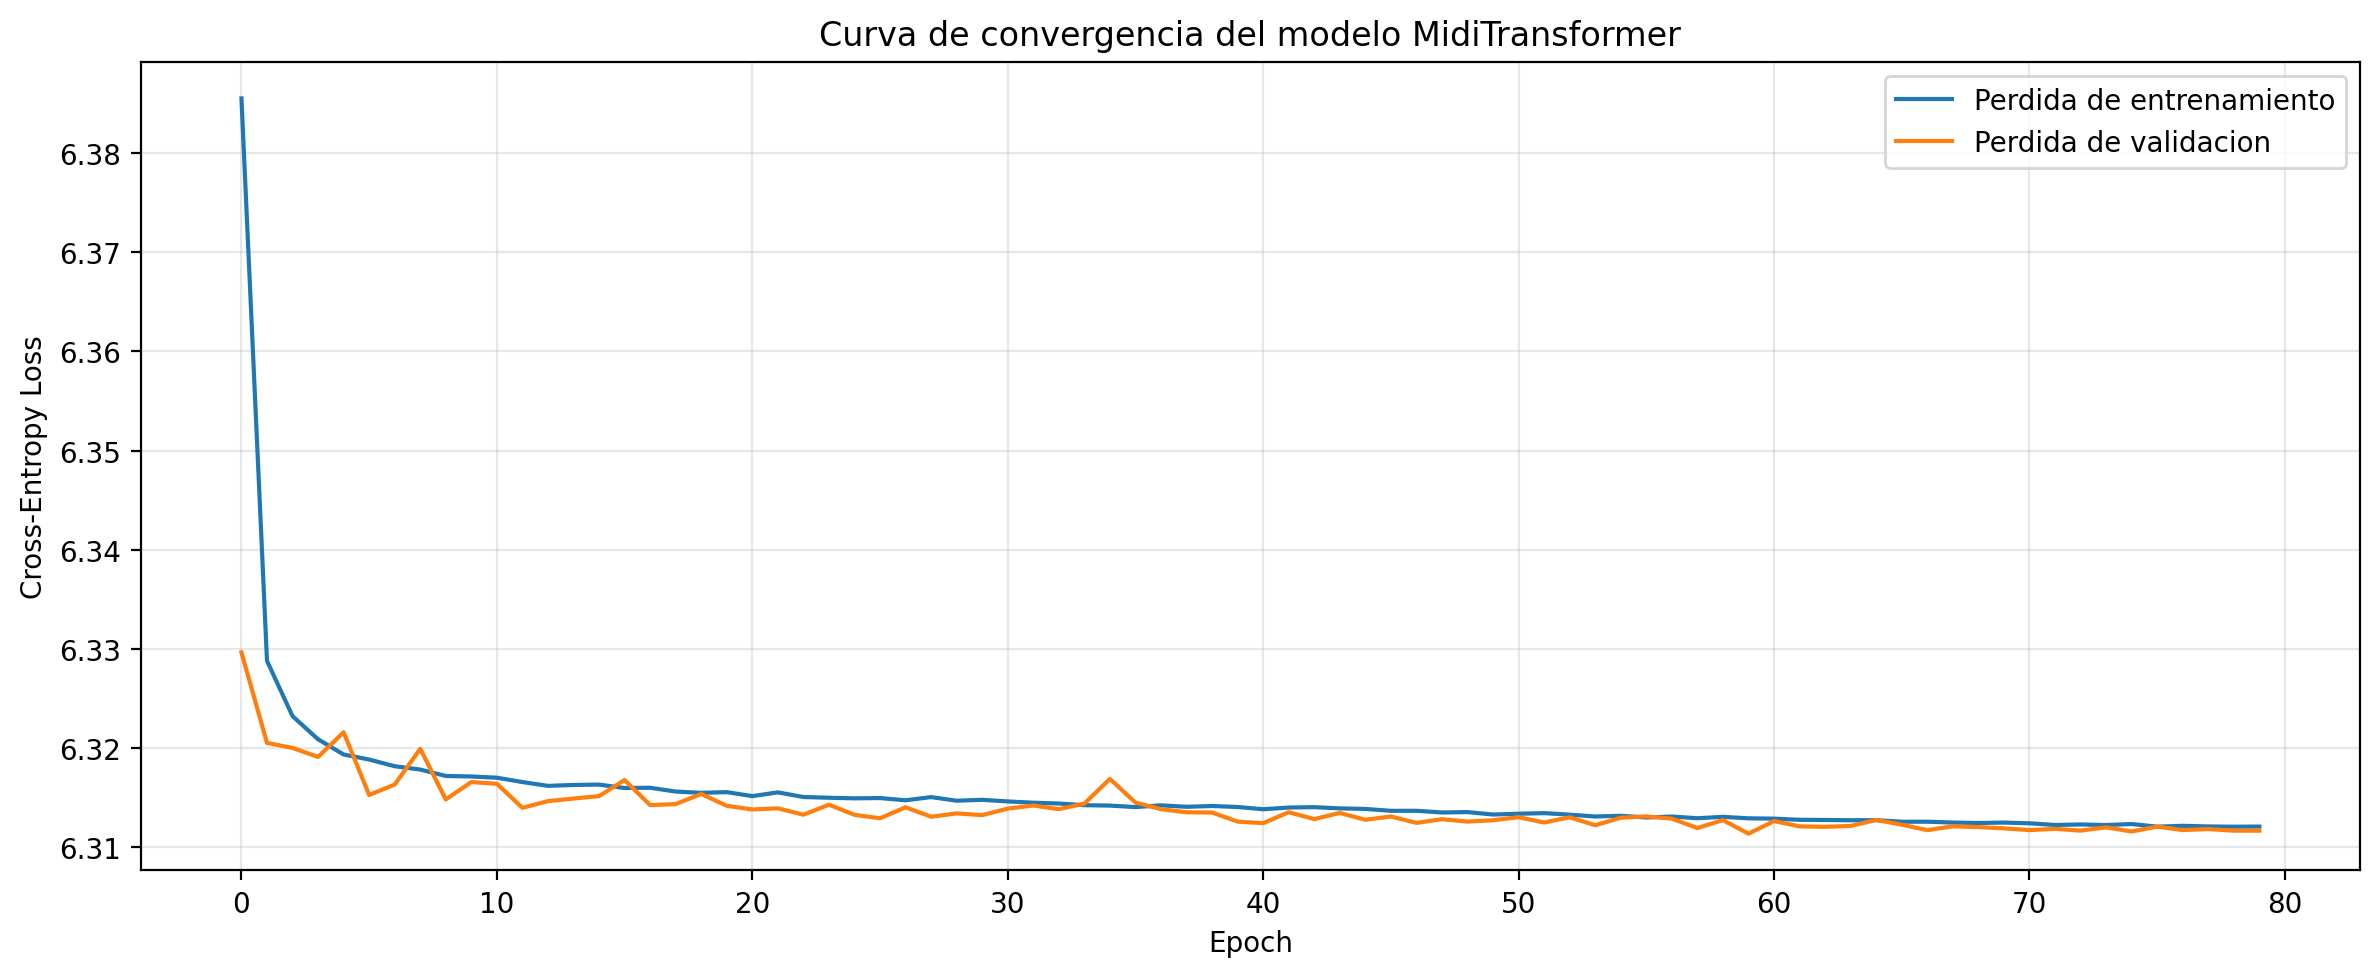

Loss inicial (epoch 1):   6.3855
Loss final (epoch 80): 6.3121
Reduccion de perdida:     1.1%


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_losses, label='Perdida de entrenamiento', linewidth=1.5)
ax.plot(val_losses,   label='Perdida de validacion',    linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Curva de convergencia del modelo MidiTransformer')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curve.png', dpi=150)
plt.show()

print(f'Loss inicial (epoch 1):   {train_losses[0]:.4f}')
print(f'Loss final (epoch {len(train_losses)}): {train_losses[-1]:.4f}')
print(f'Reduccion de perdida:     {(1 - train_losses[-1]/train_losses[0])*100:.1f}%')

---
## Seccion 9. Generacion de nuevas composiciones MIDI

Se genera una nueva composicion musical mediante muestreo autoregresivo. El proceso comienza con una semilla de eventos extraida aleatoriamente del corpus de entrenamiento y genera de forma iterativa nuevos eventos hasta alcanzar la longitud deseada.

El parametro `temperature` controla la aleatoriedad de la generacion: valores bajos producen composiciones mas predecibles y cercanas al corpus de entrenamiento, mientras que valores altos introducen mayor variedad y creatividad a costa de posible incoherencia musical.

In [18]:
import torch
import torch.nn.functional as F
from glob import glob

# Cargar el modelo y vocabulario desde el ultimo checkpoint
checkpoints = sorted(glob(f'{SAVE_DIR}/checkpoint_epoch*.pt'))
ckpt_path   = checkpoints[-1] if checkpoints else f'{SAVE_DIR}/model_final.pt'
ckpt        = torch.load(ckpt_path, map_location=device)

vocab        = ckpt['vocab']
token_to_idx = vocab['token_to_idx']
idx_to_token = vocab['idx_to_token']
dur_to_idx   = vocab['dur_to_idx']
idx_to_dur   = vocab['idx_to_dur']
vocab_size     = vocab['vocab_size']
dur_vocab_size = vocab['dur_vocab_size']

model = MidiTransformer(
    vocab_size=vocab_size, dur_vocab_size=dur_vocab_size,
    d_model=256, nhead=8, num_layers=6,
    dim_feedforward=1024, dropout=0.1, seq_len=SEQ_LEN
).to(device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'Modelo cargado desde: {ckpt_path}')


def generate_midi_events(model, token_seq, dur_seq, n_events=512,
                          temperature=1.0, seq_len=128):
    """
    Genera una secuencia de eventos MIDI mediante muestreo autoregresivo.

    Parametros:
        model:       modelo Transformer entrenado
        token_seq:   secuencia de indices de tokens del corpus (semilla)
        dur_seq:     secuencia de indices de duraciones del corpus (semilla)
        n_events:    numero de eventos a generar
        temperature: factor de escala de los logits (1.0 = sin modificar)
        seq_len:     longitud de la ventana de contexto

    Devuelve:
        Lista de tuplas (token, duracion) con los eventos generados
    """
    import random

    # Seleccionar semilla aleatoria del corpus
    start = random.randint(0, len(token_seq) - seq_len - 1)
    ctx_tokens = list(token_seq[start:start + seq_len])
    ctx_durs   = list(dur_seq[start:start + seq_len])
    generated  = []

    for _ in range(n_events):
        x_t = torch.tensor([ctx_tokens[-seq_len:]], dtype=torch.long).to(device)
        x_d = torch.tensor([ctx_durs[-seq_len:]],   dtype=torch.long).to(device)

        with torch.no_grad():
            pred_t, pred_d = model(x_t, x_d)

        # Muestreo con temperature sobre el ultimo token predicho
        logits_t = pred_t[0, -1] / temperature
        logits_d = pred_d[0, -1] / temperature
        next_t   = torch.multinomial(F.softmax(logits_t, dim=-1), 1).item()
        next_d   = torch.multinomial(F.softmax(logits_d, dim=-1), 1).item()

        ctx_tokens.append(next_t)
        ctx_durs.append(next_d)
        generated.append((idx_to_token[next_t], idx_to_dur[next_d]))

    return generated


# Generar 512 eventos con temperature 0.9
print('Generando composicion...')
generated_events = generate_midi_events(
    model, token_seq, dur_seq,
    n_events=512,
    temperature=0.9,
    seq_len=SEQ_LEN
)
print(f'Eventos generados: {len(generated_events)}')
print(f'Primeros 10: {generated_events[:10]}')

Modelo cargado desde: /content/drive/MyDrive/midi_transformer/checkpoint_epoch0080.pt
Generando composicion...
Eventos generados: 512
Primeros 10: [('G2.D3', 0.25), ('C#2.G#2', 0.25), ('B2.F#3.B3', 0.5), ('A5', 0.25), ('D4', 0.5), ('F#5', 1.0), ('A4', 0.5), ('C3', 0.5), ('B2.F#3.B3', 0.5), ('G3', 0.25)]


---
## Seccion 10. Conversion de eventos generados a archivo MIDI

Se reconstruye un archivo MIDI a partir de la secuencia de eventos generados por el modelo. Cada token se convierte de vuelta a un objeto Note o Chord de music21 con su duracion correspondiente, y se exporta como archivo .mid.

In [19]:
from music21 import stream, note, chord, duration
import os

def events_to_midi(events, output_path, tempo=120):
    """
    Convierte una lista de eventos (token, duracion) a un archivo MIDI.

    Parametros:
        events:      lista de tuplas (token_str, duracion_float)
        output_path: ruta del archivo MIDI de salida
        tempo:       tempo en BPM
    """
    output_stream = stream.Stream()

    for token_str, dur_val in events:
        dur_obj = duration.Duration(quarterLength=float(dur_val))

        if '.' in token_str:
            # Es un acorde: reconstruir desde los nombres de tono
            pitches = token_str.split('.')
            try:
                c = chord.Chord(pitches, duration=dur_obj)
                output_stream.append(c)
            except Exception:
                pass
        else:
            # Es una nota individual
            try:
                n = note.Note(token_str, duration=dur_obj)
                output_stream.append(n)
            except Exception:
                pass

    output_stream.write('midi', fp=output_path)


os.makedirs('/content/generated_midi', exist_ok=True)
MIDI_OUTPUT = '/content/generated_midi/composition_generated.mid'

events_to_midi(generated_events, MIDI_OUTPUT)
print(f'Archivo MIDI generado: {MIDI_OUTPUT}')

Archivo MIDI generado: /content/generated_midi/composition_generated.mid


# Seccion 10b. Verificacion auditiva del MIDI generado

 Para reproducir el MIDI en Colab es necesario sintetizarlo a WAV primero.
 Se utiliza el soundfont de SM64 disponible para generar una previsualizacion
 auditiva antes de proceder a la sintesis final de la seccion 11.

In [20]:


import subprocess
import librosa
import IPython.display as ipd

MIDI_PREVIEW = '/content/generated_midi/preview.wav'

subprocess.run([
    'fluidsynth', '-ni',
    '-F', MIDI_PREVIEW,
    '-r', '22050',
    '-g', '0.8',
    SF2_PATH,
    MIDI_OUTPUT
], capture_output=True)

print('Previsualizacion del MIDI generado:')
a, sr = librosa.load(MIDI_PREVIEW, sr=None)
ipd.display(ipd.Audio(a, rate=sr))

Output hidden; open in https://colab.research.google.com to view.

Se puede comprobar que la canción que genera coge un poco de todo y que no genera una canción con su propia estructura, si no que aprende un poco de la estructura de todas.
Es capaz de generar una canción pero no es capaz de encontrar la estructura de las canciones.

---
## Seccion 11. Sintesis de audio con FluidSynth y el soundfont de SM64

El archivo MIDI generado por el modelo se sintetiza a audio WAV utilizando FluidSynth con el soundfont de Super Mario 64, aplicando asi el timbre caracteristico del hardware de Nintendo 64 a la nueva composicion.

In [21]:
import subprocess
import IPython.display as ipd
import librosa

os.makedirs('/content/generated_wav', exist_ok=True)
WAV_OUTPUT = '/content/generated_wav/composition_generated.wav'

def render_midi(midi_path, output_path, sf2_path, sample_rate=32000):
    """
    Sintetiza un archivo MIDI a WAV utilizando FluidSynth con el soundfont de SM64.
    """
    cmd = [
        'fluidsynth', '-ni',
        '-F', output_path,
        '-r', str(sample_rate),
        '-g', '0.8',
        '-o', 'synth.reverb.active=yes',
        '-o', 'synth.chorus.active=yes',
        '-o', f'synth.sample-rate={sample_rate}',
        '-o', 'audio.period-size=1024',
        sf2_path, midi_path
    ]
    return subprocess.run(cmd, capture_output=True)


render_midi(MIDI_OUTPUT, WAV_OUTPUT, SF2_PATH)

if os.path.exists(WAV_OUTPUT):
    print(f'Audio sintetizado: {WAV_OUTPUT}')
    a, sr = librosa.load(WAV_OUTPUT, sr=None)
    print(f'Duracion: {len(a)/sr:.1f} segundos')
    ipd.display(ipd.Audio(WAV_OUTPUT))
else:
    print('Error en la sintesis. Verificar FluidSynth y el soundfont.')

Output hidden; open in https://colab.research.google.com to view.

---
## Seccion 12. Exportacion de resultados

In [22]:
from google.colab import files
import shutil

# Copiar resultados a Drive
shutil.copy(MIDI_OUTPUT, f'{SAVE_DIR}/composition_generated.mid')
shutil.copy(WAV_OUTPUT,  f'{SAVE_DIR}/composition_generated.wav')

# Descargar localmente
files.download(MIDI_OUTPUT)
files.download(WAV_OUTPUT)

print('Exportacion completada.')
print(f'Archivos disponibles en: {SAVE_DIR}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exportacion completada.
Archivos disponibles en: /content/drive/MyDrive/midi_transformer
